In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from collections import Counter
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from sklearn.metrics import classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

/home5/s6398820/projects/LT_project/lt_env/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_df = pd.read_csv("../logic_data/edu_train.csv", usecols=["source_article", "updated_label"])
dev_df   = pd.read_csv("../logic_data/edu_dev.csv", usecols=["source_article", "updated_label"])
test_df  = pd.read_csv("../logic_data/edu_test.csv", usecols=["source_article", "updated_label"])

print(f"Train: {len(train_df)}  Dev: {len(dev_df)}  Test: {len(test_df)}")
train_df.head()

Train: 1849  Dev: 300  Test: 300


,source_article,updated_label
0,"company's slogan ""Expect More. Pay Less.""",appeal to emotion
1,"The bigger a child's shoe size, the better the...",false causality
2,"Since many people believe this, then it must b...",ad populum
3,Senator Randall isn't lying when she says she ...,circular reasoning
4,A mother is telling her daughter that she went...,fallacy of relevance


In [3]:
from datasets import Dataset, DatasetDict

raw_datasets = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "dev": Dataset.from_pandas(dev_df),
    "test": Dataset.from_pandas(test_df)
})

print("Datasets built successfully. Sizes:", raw_datasets)

Datasets built successfully. Sizes: DatasetDict({
    train: Dataset({
        features: ['source_article', 'updated_label'],
        num_rows: 1849
    })
    dev: Dataset({
        features: ['source_article', 'updated_label'],
        num_rows: 300
    })
    test: Dataset({
        features: ['source_article', 'updated_label'],
        num_rows: 300
    })
})


In [4]:
label_list = sorted(list(set(train_df["updated_label"].unique()) |
                         set(dev_df["updated_label"].unique()) |
                         set(test_df["updated_label"].unique())))
num_labels = len(label_list)
print(f"Number of labels: {num_labels}")
print(f"Labels: {label_list}")

label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for l, i in label2id.items()}

Number of labels: 13
Labels: ['ad hominem', 'ad populum', 'appeal to emotion', 'circular reasoning', 'equivocation', 'fallacy of credibility', 'fallacy of extension', 'fallacy of logic', 'fallacy of relevance', 'false causality', 'false dilemma', 'faulty generalization', 'intentional']


In [5]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 11134.92it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [6]:
def preprocess_function(examples):
    return tokenizer(examples['source_article'], truncation=True, padding="max_length", max_length=128)

tokenized_datasets = raw_datasets.map(preprocess_function, batched=True, remove_columns=['source_article'])

def label_to_id(example):
    example['labels'] = label2id[example['updated_label']]
    return example

tokenized_datasets = tokenized_datasets.map(label_to_id)
tokenized_datasets = tokenized_datasets.remove_columns(['updated_label'])
tokenized_datasets.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map: 100%|██████████| 300/300 [00:00<00:00, 29111.61 examples/s]


In [7]:
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import classification_report

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    report = classification_report(labels, predictions, target_names=label_list, output_dict=True, zero_division=0)
    return {
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "accuracy": report["accuracy"]
    }

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=10,
    report_to="none",
    seed=SEED,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [8]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["dev"],
    compute_metrics=compute_metrics
)

print("Starting training...")
trainer.train()

Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Starting training...


Epoch,Training Loss,Validation Loss,Macro F1,Weighted F1,Accuracy
1,1.700212,1.557294,0.448985,0.536512,0.546667
2,1.032499,1.142867,0.554603,0.636848,0.643333
3,0.674185,1.067172,0.625618,0.697696,0.703333


Writing model shards: 100%|██████████| 1/1 [00:04<00:00,  4.24s/it]


TrainOutput(global_step=348, training_loss=1.3547596410773266, metrics={'train_runtime': 62.2631, 'train_samples_per_second': 89.09, 'train_steps_per_second': 5.589, 'total_flos': 364905292172544.0, 'train_loss': 1.3547596410773266, 'epoch': 3.0})

In [9]:
test_results = trainer.evaluate(tokenized_datasets['test'])
print("Test set results:")
for k, v in test_results.items():
    print(f"  {k}: {v:.4f}")

Training Loss,Validation Loss,Epoch,Macro F1,Weighted F1,Accuracy
0.674185,1.298117,3,0.539883,0.613125,0.626667


Test set results:
  eval_loss: 1.2981
  eval_macro_f1: 0.5399
  eval_weighted_f1: 0.6131
  eval_accuracy: 0.6267


In [10]:
predictions = trainer.predict(tokenized_datasets['test'])
preds = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

print("\nDetailed Classification Report:")
print(classification_report(true_labels, preds, target_names=label_list, zero_division=0))


Detailed Classification Report:
                        precision    recall  f1-score   support

            ad hominem       0.78      0.76      0.77        41
            ad populum       0.68      0.90      0.77        30
     appeal to emotion       0.64      0.61      0.62        23
    circular reasoning       0.52      0.58      0.55        19
          equivocation       0.00      0.00      0.00         5
fallacy of credibility       0.50      0.41      0.45        17
  fallacy of extension       0.55      0.52      0.54        21
      fallacy of logic       0.50      0.43      0.46        14
  fallacy of relevance       0.40      0.25      0.31        24
       false causality       0.60      0.67      0.63        18
         false dilemma       0.73      0.92      0.81        12
 faulty generalization       0.73      0.75      0.74        61
           intentional       0.33      0.40      0.36        15

              accuracy                           0.63       300
     

In [11]:
os.makedirs('../results/baseline_roberta', exist_ok=True)
results_df = pd.DataFrame({
    'text': test_df['source_article'].tolist(),
    'true': [label_list[i] for i in true_labels],
    'pred': [label_list[i] for i in preds],
    'correct': [int(t == p) for t, p in zip(true_labels, preds)],
})
results_path = '../results/baseline_roberta/roberta_results.csv'
results_df.to_csv(results_path, index=False)
print(f'Results saved to {results_path}')

Results saved to ../results/baseline_roberta/roberta_results.csv


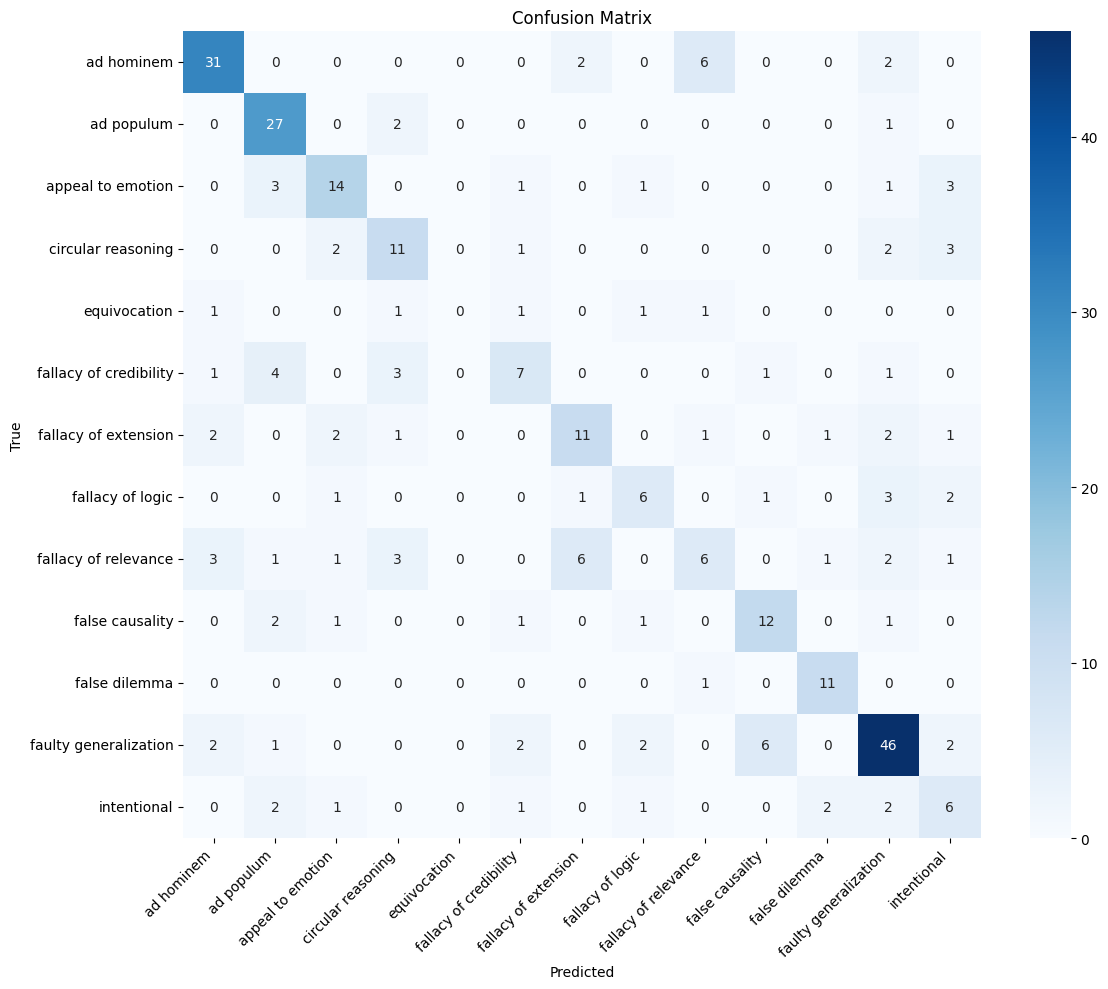

In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(true_labels, preds)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_list, yticklabels=label_list, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [13]:
import pandas as pd

test_texts = pd.read_csv("../logic_data/edu_test.csv")["source_article"].tolist()
error_indices = [i for i, (t, p) in enumerate(zip(true_labels, preds)) if t != p]

print(f"Total errors: {len(error_indices)} / {len(true_labels)}")
print(f"Error rate: {len(error_indices)/len(true_labels)*100:.1f}%")
print()

error_df = pd.DataFrame({
    "text": [test_texts[i] for i in error_indices],
    "true": [label_list[true_labels[i]] for i in error_indices],
    "predicted": [label_list[preds[i]] for i in error_indices]
})

confusion_pairs = error_df.groupby(["true", "predicted"]).size().sort_values(ascending=False)
print("Top confused pairs:")
print(confusion_pairs.head(10))

Total errors: 112 / 300
Error rate: 37.3%

Top confused pairs:
true                    predicted            
ad hominem              fallacy of relevance     6
fallacy of relevance    fallacy of extension     6
faulty generalization   false causality          6
fallacy of credibility  ad populum               4
circular reasoning      intentional              3
appeal to emotion       intentional              3
fallacy of relevance    ad hominem               3
                        circular reasoning       3
fallacy of credibility  circular reasoning       3
fallacy of logic        faulty generalization    3
dtype: int64


In [14]:
for (true_label, pred_label), count in confusion_pairs.head(5).items():
    print(f"\n=== {true_label} -> {pred_label} ({count} errors) ===")
    subset = error_df[(error_df["true"] == true_label) & (error_df["predicted"] == pred_label)]
    for _, row in subset.head(2).iterrows():
        text_preview = row["text"][:120]
        print(f"  {text_preview}...")


=== ad hominem -> fallacy of relevance (6 errors) ===
  President Trump said that he was proud of the children who participated in this year's Special Olympics. Those kids are ...
  Personally attacking someone to shift attention away from your views is...

=== fallacy of relevance -> fallacy of extension (6 errors) ===
  "My opponent claims that water pollution is endangering our city waters. But have you thought about all of the air pollu...
  I don't think that there should be marriage among homosexuals. Anyway, taxes on married people are high. I think that ta...

=== faulty generalization -> false causality (6 errors) ===
  We should go inside; the last time the clouds were that dark, there was a tornado....
  “She was wearing cowboy boots in her last Instagram picture so she must be into country music.”...

=== fallacy of credibility -> ad populum (4 errors) ===
  Bill: Hey, did you hear we have a new operating system out now?  It is better than anything else out there because w

In [15]:
print("=" * 60)
print("One error example per true label (for presentation)")
print("=" * 60)
print()

for true_label in sorted(error_df["true"].unique()):
    subset = error_df[error_df["true"] == true_label]
    best = subset.groupby("predicted").size().idxmax()
    example = subset[subset["predicted"] == best].iloc[0]
    print(f"True: {true_label}")
    print(f"Pred: {example['predicted']}")
    print(f"Text: {example['text']}")
    print()

One error example per true label (for presentation)

True: ad hominem
Pred: fallacy of relevance
Text: President Trump said that he was proud of the children who participated in this year's Special Olympics. Those kids are a bunch of losers.

True: ad populum
Pred: circular reasoning
Text: The Freehold Raceway Mall is the best mall because there are always so many cars there.

True: appeal to emotion
Pred: ad populum
Text: Using positive words that become associated with something, like company slogans and political advertisements

True: circular reasoning
Pred: intentional
Text: Repeating the same thing as if you’re proving something

True: equivocation
Pred: ad hominem
Text: I don't see how you can say you're an ethical person. It's so hard to get you to do anything; your work ethic is so bad

True: fallacy of credibility
Pred: ad populum
Text: Bill: Hey, did you hear we have a new operating system out now?  It is better than anything else out there because we just released it!
Steve